# Supervised Fishing Effort Classification - User Guide
 
This notebook demonstrates how to use the `ssfaitk` library to classify fishing vessel activities
(fishing/searching vs. sailing/traveling) from GPS tracking data.

## Overview
- Load your GPS tracking data
- Use pre-trained Random Forest model to predict fishing effort
- Evaluate predictions and visualize results
- Export predictions for further analysis

## 1. Installation & Imports

In [1]:
# Standard imports
import random

# Visualization (optional)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Metrics for evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# SSF AI Toolkit - Effort Classification
from ssfaitk.models import EffortClassifier

## 2. Load Your Data

### Required Columns:
Your CSV must contain at minimum:
- `Trip_ID`: Unique identifier for each fishing trip
- `Latitude`: Latitude in decimal degrees
- `Longitude`: Longitude in decimal degrees  
- `ltime`: Timestamp (will be converted to datetime automatically)

### Optional Column (for evaluation):
- `Activity`: Ground truth labels ('Fishing', 'Searching', 'Sailing', 'Traveling')

In [2]:
# Path to your GPS tracking data
data_path = "../../data/dfKenyaAll_Tracks_df_cleaned.csv"

# Load the data
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()


Dataset loaded successfully!
Shape: (193934, 17)

Columns: ['Observer', 'Date', 'ident', 'Latitude', 'Longitude', 'y_proj', 'x_proj', 'new_trk', 'new_seg', 'altitude', 'model', 'ltime', 'time_EAT', 'Location', 'Activity', 'Trip_Haul_ID', 'Trip_ID']

First few rows:


/var/folders/kj/2hjk7hzn2qz7f8rsq4mzqnm40000gp/T/ipykernel_52527/3889965945.py:5: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


,Observer,Date,ident,Latitude,Longitude,y_proj,x_proj,new_trk,new_seg,altitude,model,ltime,time_EAT,Location,Activity,Trip_Haul_ID,Trip_ID
0,Abudhabi Jambia,2016-01-06,65_H_2_F,-4.526989,39.503832,-4.526989,39.503832,NaN,NaN,NaN,legacy 2015_16 data,2016/01/06 08:48:00,2016-01-06 08:48:00,Gazi,Fishing,62_2,62
1,Abudhabi Jambia,2016-01-06,65_H_2_F,-4.527075,39.503274,-4.527075,39.503274,NaN,NaN,NaN,legacy 2015_16 data,2016/01/06 08:50:00,2016-01-06 08:50:00,Gazi,Fishing,62_2,62
2,Abudhabi Jambia,2016-01-06,65_H_2_F,-4.524565,39.504626,-4.524565,39.504626,NaN,NaN,NaN,legacy 2015_16 data,2016/01/06 08:52:00,2016-01-06 08:52:00,Gazi,Fishing,62_2,62
3,Abudhabi Jambia,2016-01-06,65_H_2_F,-4.524114,39.504347,-4.524114,39.504347,NaN,NaN,NaN,legacy 2015_16 data,2016/01/06 08:54:00,2016-01-06 08:54:00,Gazi,Fishing,62_2,62
4,Abudhabi Jambia,2016-01-06,65_H_2_F,-4.523449,39.505055,-4.523449,39.505055,NaN,NaN,NaN,legacy 2015_16 data,2016/01/06 08:56:00,2016-01-06 08:56:00,Gazi,Fishing,62_2,62


## 3. Data Validation

Let's verify that your data has the required columns and basic quality checks.

In [3]:
# Check required columns
required_cols = ['Trip_ID', 'Latitude', 'Longitude', 'ltime']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")
else:
    print("✓ All required columns present")

# Check for missing values in critical columns
print("\nMissing values:")
print(df[required_cols].isnull().sum())

# Check data ranges
print("\nData ranges:")
print(f"  Latitude: [{df['Latitude'].min():.4f}, {df['Latitude'].max():.4f}]")
print(f"  Longitude: [{df['Longitude'].min():.4f}, {df['Longitude'].max():.4f}]")
print(f"  Number of trips: {df['Trip_ID'].nunique()}")
print(f"  Date range: {pd.to_datetime(df['ltime']).min()} to {pd.to_datetime(df['ltime']).max()}")


✓ All required columns present

Missing values:
Trip_ID      0
Latitude     0
Longitude    0
ltime        0
dtype: int64

Data ranges:
  Latitude: [-4.8554, -2.4828]
  Longitude: [39.1943, 40.5413]
  Number of trips: 239
  Date range: 2015-12-21 06:46:00 to 2018-04-07 12:55:22


## 4. Load Pre-trained Model

The library comes with a pre-trained Random Forest classifier.
The model will automatically compute all necessary features from your raw GPS data.

In [4]:
# Load the pre-trained effort classifier
print("Loading pre-trained model...")
clf = EffortClassifier.load_trained(model_name="rf")

print("✓ Model loaded successfully!")
print(f"  Model uses {len(clf.feat_cols)} engineered features")

Loading pre-trained model...


/Users/altarturhamza/Library/CloudStorage/OneDrive-CGIAR/GitHub/ssf-ai-toolkit/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/altarturhamza/Library/CloudStorage/OneDrive-CGIAR/GitHub/ssf-ai-toolkit/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[INFO] 2025-11-11 14:22:08,841 ssfaitk.models.effo

✓ Model loaded successfully!
  Model uses 28 engineered features


## 5. Make Predictions

The `predict_df()` method will:
1. Automatically compute ~28 features from your GPS data (speed, acceleration, turning angles, etc.)
2. Apply the trained model
3. Return your dataframe with predictions added

**Note:** The dataframe will be sorted by `Trip_ID` and `ltime` internally.



In [5]:
# Make predictions
print("Computing features and making predictions...")
print("(This may take a few minutes for large datasets)")

predictions = clf.predict_df(df)

print("\n✓ Predictions complete!")
print(f"  Output shape: {predictions.shape}")

# Show prediction distribution
print("\nPrediction distribution:")
pred_dist = predictions['effort_pred'].value_counts(normalize=True).sort_index()
print(f"  Class 0 (Sailing/Traveling): {pred_dist[0]:.2%}")
print(f"  Class 1 (Fishing/Searching): {pred_dist[1]:.2%}")

# Display sample predictions
print("\nSample predictions:")
predictions[['Trip_ID', 'ltime', 'Latitude', 'Longitude', 'effort_pred']].head(10)



Computing features and making predictions...
(This may take a few minutes for large datasets)
computing features..


/Users/altarturhamza/Library/CloudStorage/OneDrive-CGIAR/GitHub/ssf-ai-toolkit/src/ssfaitk/models/effort/effort_classifier.py:240: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shape = df.groupby("Trip_ID", group_keys=False).apply(lambda g: _shape_windows_for_trip(g, win))



✓ Predictions complete!
  Output shape: (193934, 64)

Prediction distribution:
  Class 0 (Sailing/Traveling): 58.18%
  Class 1 (Fishing/Searching): 41.82%

Sample predictions:


,Trip_ID,ltime,Latitude,Longitude,effort_pred
0,14,2015-12-21 06:46:00,-4.75210,39.26918,1
1,14,2015-12-21 06:47:00,-4.75197,39.26918,1
2,14,2015-12-21 06:47:00,-4.75185,39.26915,1
3,14,2015-12-21 06:47:00,-4.75178,39.26913,1
4,14,2015-12-21 06:48:00,-4.75173,39.26910,1
5,14,2015-12-21 06:48:00,-4.75172,39.26908,1
6,14,2015-12-21 06:49:00,-4.75170,39.26903,1
7,14,2015-12-21 06:49:00,-4.75172,39.26900,1
8,14,2015-12-21 06:49:00,-4.75172,39.26897,1
9,14,2015-12-21 06:50:00,-4.75175,39.26883,1


## 6. Evaluate Predictions (if ground truth available)

If your dataset has an `Activity` column with ground truth labels, you can evaluate model performance.


Ground truth labels found - evaluating model performance...

MODEL PERFORMANCE

Overall Accuracy: 0.9612
Weighted F1-Score: 0.9613

Detailed Classification Report:
                   precision    recall  f1-score   support

Sailing/Traveling     0.9739    0.9600    0.9669    114473
Fishing/Searching     0.9436    0.9630    0.9532     79461

         accuracy                         0.9612    193934
        macro avg     0.9587    0.9615    0.9600    193934
     weighted avg     0.9615    0.9612    0.9613    193934



/var/folders/kj/2hjk7hzn2qz7f8rsq4mzqnm40000gp/T/ipykernel_52527/4066086473.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_true = predictions['Activity'].replace({


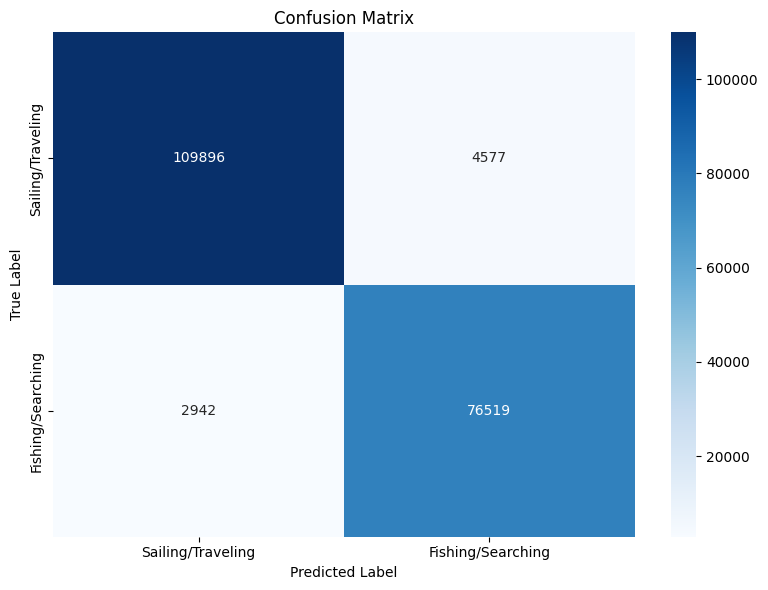

In [6]:
if 'Activity' in predictions.columns:
    print("Ground truth labels found - evaluating model performance...")
    
    # Create binary ground truth labels
    # 1 = Fishing/Searching (active fishing)
    # 0 = Sailing/Traveling (transit)
    y_true = predictions['Activity'].replace({
        'Fishing': 1,
        'Searching': 1,
        'Sailing': 0,
        'Traveling': 0
    }).fillna(0).astype(int)
    
    y_pred = predictions['effort_pred'].values
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'='*60}")
    print("MODEL PERFORMANCE")
    print(f"{'='*60}")
    print(f"\nOverall Accuracy: {accuracy:.4f}")
    print(f"Weighted F1-Score: {f1_weighted:.4f}")
    
    print("\nDetailed Classification Report:")
    print(classification_report(
        y_true, 
        y_pred, 
        target_names=['Sailing/Traveling', 'Fishing/Searching'],
        digits=4
    ))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Sailing/Traveling', 'Fishing/Searching'],
                yticklabels=['Sailing/Traveling', 'Fishing/Searching'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
else:
    print("No ground truth labels (Activity column) found.")
    print("Skipping evaluation step.")

## 7. Analyze Predictions by Trip

Summarize predictions at the trip level to understand fishing effort per trip.




TRIP-LEVEL SUMMARY

Total trips analyzed: 239

Top 10 trips by fishing effort:
         total_points  fishing_points  fishing_ratio          start_time  \
Trip_ID                                                                    
14                319             319         1.0000 2015-12-21 06:46:00   
327               172             172         1.0000 2017-06-05 06:31:35   
368                12              12         1.0000 2017-06-19 08:26:12   
268                38              36         0.9474 2017-05-13 07:11:33   
271               223             197         0.8834 2017-05-14 06:41:26   
146              1153            1017         0.8820 2017-03-23 06:18:16   
251               329             284         0.8632 2017-05-07 07:20:00   
162              1241            1064         0.8574 2017-03-29 06:15:08   
401               126             108         0.8571 2017-07-02 07:04:23   
150              1339            1132         0.8454 2017-03-25 06:18:26   

       

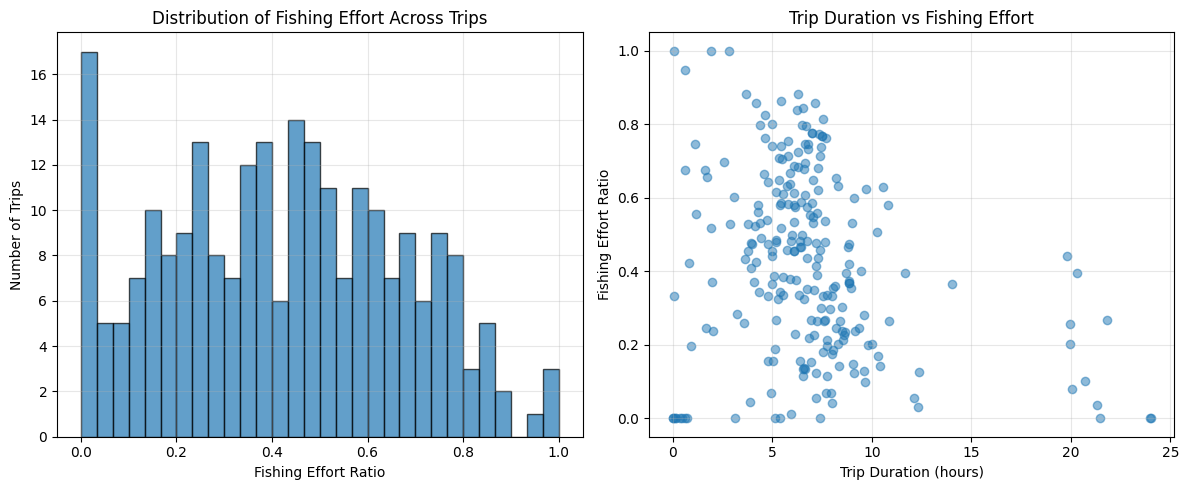

In [7]:
# Calculate trip-level statistics
trip_summary = predictions.groupby('Trip_ID').agg({
    'effort_pred': ['count', 'sum', 'mean'],
    'ltime': ['min', 'max']
}).round(4)

trip_summary.columns = ['total_points', 'fishing_points', 'fishing_ratio', 'start_time', 'end_time']

# Calculate trip duration
trip_summary['duration_hours'] = (
    pd.to_datetime(trip_summary['end_time']) - 
    pd.to_datetime(trip_summary['start_time'])
).dt.total_seconds() / 3600

# Sort by fishing ratio
trip_summary = trip_summary.sort_values('fishing_ratio', ascending=False)

print(f"\n{'='*80}")
print("TRIP-LEVEL SUMMARY")
print(f"{'='*80}")
print(f"\nTotal trips analyzed: {len(trip_summary)}")
print("\nTop 10 trips by fishing effort:")
print(trip_summary.head(10))

# Visualize fishing effort distribution across trips
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(trip_summary['fishing_ratio'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Fishing Effort Ratio')
plt.ylabel('Number of Trips')
plt.title('Distribution of Fishing Effort Across Trips')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(trip_summary['duration_hours'], trip_summary['fishing_ratio'], alpha=0.5)
plt.xlabel('Trip Duration (hours)')
plt.ylabel('Fishing Effort Ratio')
plt.title('Trip Duration vs Fishing Effort')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 8. Add Human-Readable Labels

Convert numeric predictions to descriptive labels for better interpretability.


In [8]:
# Add readable activity labels
predictions['predicted_activity'] = predictions['effort_pred'].map({
    0: 'Sailing/Traveling',
    1: 'Fishing/Searching'
})

# Show distribution
print("\nPredicted Activity Distribution:")
print(predictions['predicted_activity'].value_counts())

# Display sample with labels
print("\nSample predictions with labels:")
sample_cols = ['Trip_ID', 'ltime', 'Latitude', 'Longitude', 'effort_pred', 'predicted_activity']
if 'Activity' in predictions.columns:
    sample_cols.insert(-1, 'Activity')

predictions[sample_cols].head(20)




Predicted Activity Distribution:
predicted_activity
Sailing/Traveling    112838
Fishing/Searching     81096
Name: count, dtype: int64

Sample predictions with labels:


,Trip_ID,ltime,Latitude,Longitude,effort_pred,Activity,predicted_activity
0,14,2015-12-21 06:46:00,-4.75210,39.26918,1,Searching,Fishing/Searching
1,14,2015-12-21 06:47:00,-4.75197,39.26918,1,Searching,Fishing/Searching
2,14,2015-12-21 06:47:00,-4.75185,39.26915,1,Searching,Fishing/Searching
3,14,2015-12-21 06:47:00,-4.75178,39.26913,1,Searching,Fishing/Searching
4,14,2015-12-21 06:48:00,-4.75173,39.26910,1,Searching,Fishing/Searching
5,14,2015-12-21 06:48:00,-4.75172,39.26908,1,Searching,Fishing/Searching
6,14,2015-12-21 06:49:00,-4.75170,39.26903,1,Searching,Fishing/Searching
7,14,2015-12-21 06:49:00,-4.75172,39.26900,1,Searching,Fishing/Searching
8,14,2015-12-21 06:49:00,-4.75172,39.26897,1,Searching,Fishing/Searching
9,14,2015-12-21 06:50:00,-4.75175,39.26883,1,Searching,Fishing/Searching


## 9. Export Results

Save predictions to CSV for further analysis or visualization in GIS software.


In [9]:
# Select columns to export
export_cols = ['Trip_ID', 'ltime', 'Latitude', 'Longitude', 'effort_pred', 'predicted_activity']

# Add original Activity column if it exists
if 'Activity' in predictions.columns:
    export_cols.insert(-1, 'Activity')

# Optionally add computed features (speed, acceleration, etc.)
feature_cols_to_export = ['speed_kmh', 'acceleration', 'turn_angle', 'straightness_w']
available_feature_cols = [col for col in feature_cols_to_export if col in predictions.columns]
export_cols.extend(available_feature_cols)

# Export to CSV
output_path = "predictions_output.csv"
predictions[export_cols].to_csv(output_path, index=False)

print(f"✓ Predictions exported to: {output_path}")
print(f"  Exported {len(predictions)} rows")
print(f"  Columns: {export_cols}")



✓ Predictions exported to: predictions_output.csv
  Exported 193934 rows
  Columns: ['Trip_ID', 'ltime', 'Latitude', 'Longitude', 'effort_pred', 'Activity', 'predicted_activity', 'speed_kmh', 'acceleration', 'turn_angle', 'straightness_w']


## 10. Visualize Predictions on Map (Optional)

Create a simple map visualization of predicted fishing effort.

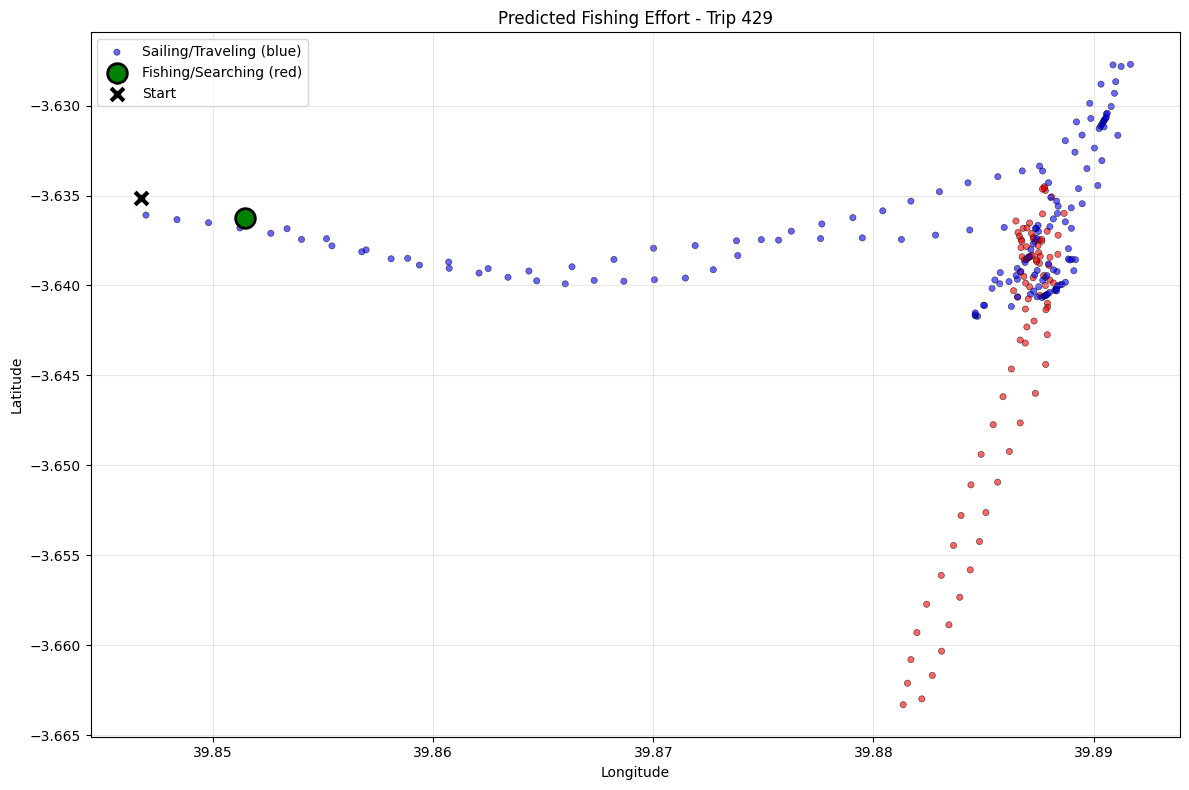


Trip 429 statistics:
  Total points: 245
  Fishing points: 91
  Fishing ratio: 37.14%


In [10]:
# Sample one trip for visualization
sample_trip_id = random.choice(predictions['Trip_ID'].unique()) # 260

sample_trip = predictions[predictions['Trip_ID'] == sample_trip_id].copy()

# Create color map for predictions
colors = sample_trip['effort_pred'].map({0: 'blue', 1: 'red'})

plt.figure(figsize=(12, 8))
plt.scatter(
    sample_trip['Longitude'], 
    sample_trip['Latitude'],
    c=colors,
    s=20,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Add start and end points
plt.scatter(
    sample_trip['Longitude'].iloc[0],
    sample_trip['Latitude'].iloc[0],
    c='green', s=200, marker='o', 
    edgecolors='black', linewidth=2,
    label='Start', zorder=5
)
plt.scatter(
    sample_trip['Longitude'].iloc[-1],
    sample_trip['Latitude'].iloc[-1],
    c='black', s=200, marker='X',
    edgecolors='white', linewidth=2,
    label='End', zorder=5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Predicted Fishing Effort - Trip {sample_trip_id}')
plt.legend(['Sailing/Traveling (blue)', 'Fishing/Searching (red)', 'Start', 'End'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTrip {sample_trip_id} statistics:")
print(f"  Total points: {len(sample_trip)}")
print(f"  Fishing points: {sample_trip['effort_pred'].sum()}")
print(f"  Fishing ratio: {sample_trip['effort_pred'].mean():.2%}")



## Summary & Best Practices

### Key Points:
1. **Always use the returned dataframe** from `predict_df()` for ground truth comparison (if evaluating)
2. **The dataframe is sorted** by Trip_ID and time internally - don't rely on original row order
3. **Feature computation is automatic** - just provide raw GPS data with required columns
4. **Model expects specific data format** - ensure Trip_ID, Latitude, Longitude, and ltime columns exist

### For Production Use:
- Validate input data format before prediction
- Handle missing values appropriately
- Monitor prediction distribution for data drift
- Save predictions with timestamps for audit trails
- Consider batch processing for very large datasets

### Need Help?
- Check documentation: [link to docs]
- Report issues: [link to GitHub issues]
- Contact support: [email/contact info]

In [29]:
print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*80)
print("\n✓ All steps completed successfully!")
print(f"✓ Predictions saved to: {output_path}")
print("\nNext steps:")
print("  1. Review predictions in the output CSV")
print("  2. Visualize results in GIS software (QGIS, ArcGIS, etc.)")
print("  3. Use predictions for further analysis")


NOTEBOOK EXECUTION COMPLETE

✓ All steps completed successfully!
✓ Predictions saved to: predictions_output.csv

Next steps:
  1. Review predictions in the output CSV
  2. Visualize results in GIS software (QGIS, ArcGIS, etc.)
  3. Use predictions for further analysis
